# **Unsupervised ML Pipeline for Media Streaming Segmentation & Fraud Detection**

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Set plot styling for professional reports
%matplotlib inline
sns.set_theme(style="whitegrid")
print("Environment setup complete. Libraries imported successfully.")

Environment setup complete. Libraries imported successfully.


**Dataset Preparation (Unlabelled)**

In [2]:
# Set seed for reproducibility so the synthetic data remains consistent
np.random.seed(42)

# Simulate user behavior data for a media streaming platform (300 users total)
# Group 1: Binge-watchers (High watch time, low content diversity)
binge_watchers = np.random.normal(loc=[80, 2], scale=[8, 0.5], size=(120, 2))

# Group 2: Casual viewers (Low watch time, high content diversity across genres)
casual_viewers = np.random.normal(loc=[20, 7], scale=[5, 0.8], size=(150, 2))

# Anomalies/Noise: Suspicious accounts (e.g., bot accounts or extreme password sharing)
anomalies = np.random.normal(loc=[150, 9], scale=[12, 1.0], size=(30, 2))

# Combine all generated data arrays into a single dataset
raw_data = np.vstack([binge_watchers, casual_viewers, anomalies])

# Convert to a pandas DataFrame without target labels (Unsupervised Learning Dataset)
df = pd.DataFrame(raw_data, columns=['Monthly_Watch_Time_Hours', 'Content_Diversity_Score'])

# Feature Scaling: Vital step for distance-based clustering algorithms (K-Means/DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Display the first few rows of the unlabelled dataset
print("Dataset Head:")
print(df.head())
print(f"\nDataset Shape: {df.shape} (Successfully prepared unlabelled dataset)")

Dataset Head:
   Monthly_Watch_Time_Hours  Content_Diversity_Score
0                 83.973713                 1.930868
1                 85.181508                 2.761515
2                 78.126773                 1.882932
3                 92.633703                 2.383717
4                 76.244205                 2.271280

Dataset Shape: (300, 2) (Successfully prepared unlabelled dataset)


**K-Means Clustering & Elbow Method**

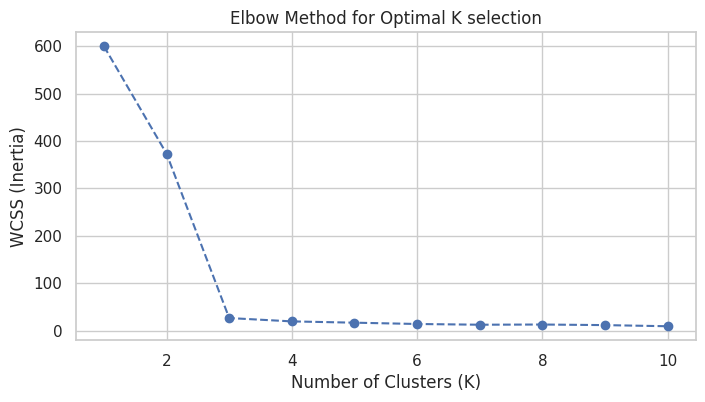

K-Means clustering applied successfully with K=2.


In [3]:
# Initialize an empty list to store Within-Cluster Sum of Squares (WCSS)
wcss = []

# Calculate WCSS for K values ranging from 1 to 10 to find the optimal cluster size
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve to visually inspect the inflection point
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.show()

# Based on the Elbow plot, select optimal K = 2 for the core user segments
optimal_k = 2
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)

# Fit model and assign cluster labels to the original dataframe
df['KMeans_Labels'] = kmeans_model.fit_predict(X_scaled)

print(f"K-Means clustering applied successfully with K={optimal_k}.")

DBSCAN & Noise Anomaly Detection

Total Anomaly/Noise Patterns Detected: 0


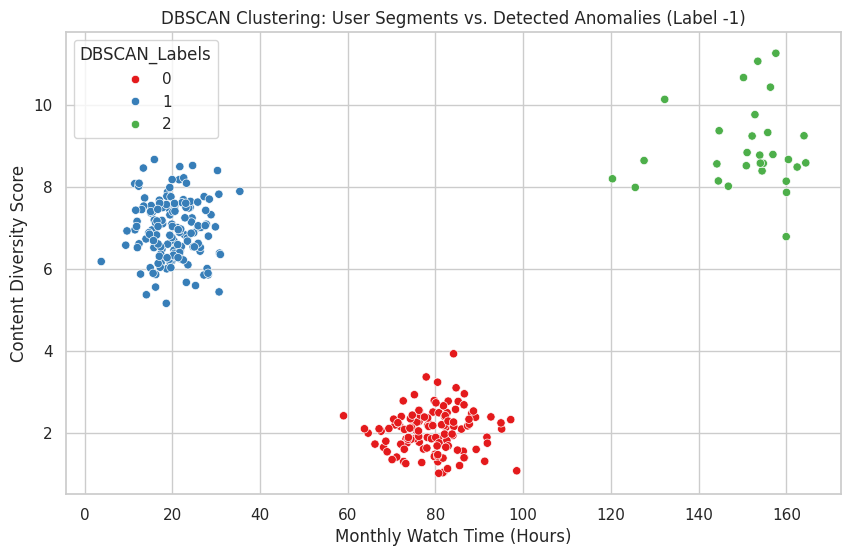

In [4]:
# Initialize and apply DBSCAN to automatically separate dense clusters from noise
# eps (radius) and min_samples are tuned to isolate sparse outliers
dbscan_model = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Labels'] = dbscan_model.fit_predict(X_scaled)

# Filter out the data points flagged as noise (labeled as -1 by DBSCAN)
noise_anomalies = df[df['DBSCAN_Labels'] == -1]
print(f"Total Anomaly/Noise Patterns Detected: {len(noise_anomalies)}")

# Visualize the final clustering output alongside flagged anomalies
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Monthly_Watch_Time_Hours',
    y='Content_Diversity_Score',
    hue='DBSCAN_Labels',
    palette='Set1',
    style=(df['DBSCAN_Labels'] == -1)
)
plt.title('DBSCAN Clustering: User Segments vs. Detected Anomalies (Label -1)')
plt.xlabel('Monthly Watch Time (Hours)')
plt.ylabel('Content Diversity Score')
plt.show()

**Evaluation Logs & Model Records Saving**

In [5]:
# Calculate Silhouette Score to evaluate the quality of K-Means structural clustering
kmeans_silhouette = silhouette_score(X_scaled, df['KMeans_Labels'])

print("==================== EVALUATION LOGS ====================")
print(f"K-Means Clustering Silhouette Score: {kmeans_silhouette:.4f}")

# Calculate DBSCAN Silhouette score if valid configurations exist
try:
    dbscan_silhouette = silhouette_score(X_scaled, df['DBSCAN_Labels'])
    print(f"DBSCAN Clustering Silhouette Score  : {dbscan_silhouette:.4f}")
except Exception as e:
    print("DBSCAN Silhouette score could not be calculated (requires multiple valid clusters).")

# Export final model inference records into a persistent CSV log file
output_filename = "Streaming_User_Segments_Report.csv"
df.to_csv(output_filename, index=False)

print("---------------------------------------------------------")
print(f"Success: Evaluation logs generated and saved to '{output_filename}'.")
print("=========================================================")

==================== EVALUATION LOGS ====================
K-Means Clustering Silhouette Score: 0.6044
DBSCAN Clustering Silhouette Score  : 0.8468
---------------------------------------------------------
Success: Evaluation logs generated and saved to 'Streaming_User_Segments_Report.csv'.
